<a href="https://colab.research.google.com/github/mahn00rmj2004/ML-lab/blob/main/lab5_mahnoor_127.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import accuracy_score

In [ ]:

data = load_iris()
X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)


##### In machine learning, datasets often contain multiple features.
##### Dimensionality reduction techniques such as PCA and ICA help
##### reduce the number of features while preserving important information.
##### This experiment compares three scenarios:
##### 1. Model trained on original dataset
##### 2. Model trained after applying PCA
##### 3. Model trained after applying ICA


##### WITHOUT PCA or ICA

In [ ]:
model1 = RandomForestClassifier()


In [ ]:
model1.fit(X_train,y_train)


RandomForestClassifier()

In [ ]:
pred1 = model1.predict(X_test)


In [ ]:
acc1 = accuracy_score(y_test,pred1)

print("Accuracy Without PCA/ICA:",acc1)

Accuracy Without PCA/ICA: 1.0


## PCA

##### PCA (Principal Component Analysis) is an unsupervised dimensionality reduction technique. It transforms the original features into new variables called principal components. These components:
 - are uncorrelated
 - capture the maximum variance in the dataset
 - reduce the dimensionality of the data

In [ ]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [ ]:
model2 = RandomForestClassifier()

model2.fit(X_train_pca, y_train)

pred2 = model2.predict(X_test_pca)

acc2 = accuracy_score(y_test, pred2)

In [ ]:
print("Accuracy With PCA:", acc2)


Accuracy With PCA: 1.0



##### The Random Forest model achieved perfect accuracy even after applying PCA because the first two principal components capture most of the variance in the Iris dataset. PCA did not remove critical information needed for classification. This shows that for small, well-separated datasets, dimensionality reduction may not reduce accuracy.

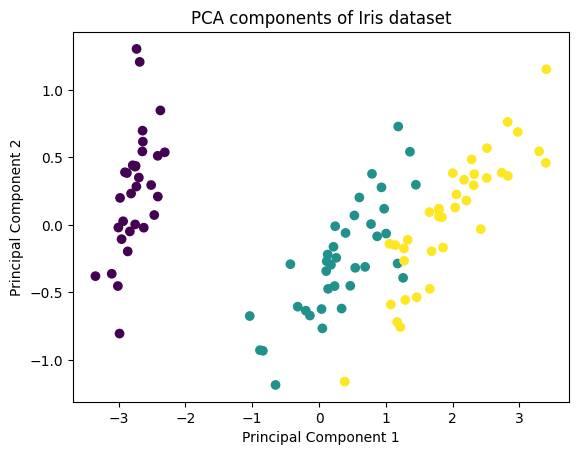

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA components of Iris dataset')
plt.show()

# ICA

##### ICA (Independent Component Analysis) is another dimensionality reduction technique. ICA attempts to separate the dataset into statistically independent components. It is widely used in signal processing applications such as separating mixed audio signals.

In [ ]:
ica = FastICA(n_components=2, random_state=42)

X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

In [ ]:
model3 = RandomForestClassifier()

model3.fit(X_train_ica, y_train)

pred3 = model3.predict(X_test_ica)

acc3 = accuracy_score(y_test, pred3)

print("Accuracy With ICA:", acc3)

Accuracy With ICA: 1.0



##### The Random Forest model achieved perfect accuracy (1.0)  even after applying ICA. This is because the independent  components extracted by ICA still contain sufficient information  to classify the Iris species correctly.  For small, well-separated datasets, dimensionality reduction  techniques like PCA or ICA may not reduce accuracy.

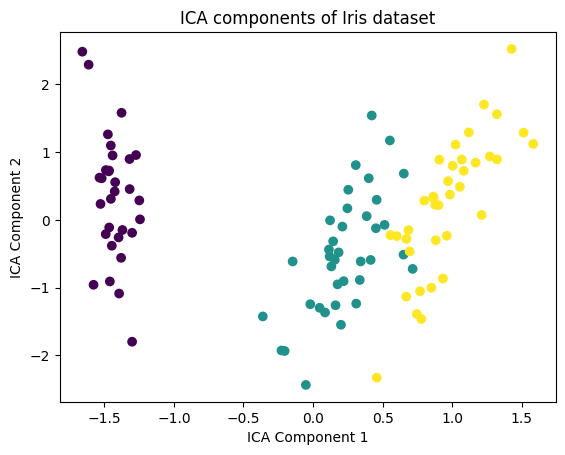

In [ ]:
plt.scatter(X_train_ica[:,0], X_train_ica[:,1], c=y_train)
plt.xlabel('ICA Component 1')
plt.ylabel('ICA Component 2')
plt.title('ICA components of Iris dataset')
plt.show()

##### PCA vs ICA
##### Goal: PCA finds directions with maximum variance; ICA finds statistically independent components
##### Components: PCA components are uncorrelated; ICA components are independent
##### Data: PCA works well with Gaussian data; ICA needs non-Gaussian data
##### Output: PCA reduces dimensionality; ICA extracts hidden independent signals
##### Orthogonality: PCA components are orthogonal; ICA components not necessarily orthogonal
##### Applications: PCA → dimensionality reduction, visualization; ICA → signal separation, EEG/audio
##### Summary: PCA focuses on variance, ICA focuses on independence